In [1]:
import numpy as np
from matplotlib import pyplot as plt
import ctypes
from ctypes import c_int64, c_int, c_double, c_void_p, byref, POINTER, Structure, c_longlong

FIXED_FRAME_SIZE = int(268000)
class PicamCameraID(ctypes.Structure):
    _fields_ = [
        ("model", c_int),
        ("computer_interface", c_int),
        ("sensor_name", ctypes.c_char * 64),
        ("serial_number", ctypes.c_char * 64),
    ]


class PicamAcquisitionErrorsMask(Structure):
    _fields_ = [("mask", c_int)]


class PicamReadout(ctypes.Structure):
    _fields_ = [
        
        ("frame_size", c_int),  # Size of the data frame
        ("data", POINTER(ctypes.c_int64)),  # Pointer to the readout data
    ]


class PicamAvailableData(Structure):
    _fields_ = [("initial_readout", c_void_p), ("readout_count", c_longlong)]


class SpectrometerController:
    def __init__(self, library_path):
        """
        Initialize the spectrometer controller.

        :param library_path: Path to the PICam shared library (DLL or .so file).
        """
        self.dll = ctypes.cdll.LoadLibrary(library_path)
        self.camera_handle = c_void_p()

    def check_error(self, error_code):
        """
        Check and raise an exception if the error code is not PicamError_None.

        :param error_code: Error code returned by a PICam function.
        """
        if error_code != 0:  # PicamError_None = 0
            raise Exception(f"PICam Error {error_code}: {self.get_error_string(error_code)}")

    def get_error_string(self, error_code):
        """
        Get a string description of the given error code.

        :param error_code: Error code returned by a PICam function.
        :return: Description of the error.
        """
        self.dll.Picam_GetEnumerationString.restype = ctypes.POINTER(ctypes.c_char_p)
        error_string = ctypes.c_char_p()
        self.dll.Picam_GetEnumerationString(c_int(1), error_code, byref(error_string))  # 1 = PicamEnumeratedType_Error
        return error_string.value.decode()

    def initialize(self):
        """Initialize the PICam library."""
        self.check_error(self.dll.Picam_InitializeLibrary())

    def uninitialize(self):
        """Uninitialize the PICam library."""
        self.check_error(self.dll.Picam_UninitializeLibrary())

    def open_camera(self, camera_id):
        """
        Open a specific camera by its ID.

        :param camera_id: An instance of PicamCameraID.
        """
        self.check_error(self.dll.Picam_OpenCamera(byref(camera_id), byref(self.camera_handle)))

    def close_camera(self):
        """Close the currently opened camera."""
        self.check_error(self.dll.Picam_CloseCamera(self.camera_handle))
        self.camera_handle = None


    def acquire_data(self, readout_count=1, timeout_ms=1000):
        """
        Acquire data from the spectrometer and ensure frame size matches the requirement.

        :param required_frame_size: Expected frame size for the acquisition.
        :param readout_count: Number of readouts to acquire.
        :param timeout_ms: Timeout in milliseconds for acquisition.
        :return: List of processed frames.
        """
        available_data = PicamAvailableData()
        errors = PicamAcquisitionErrorsMask()

        readouts = (PicamReadout * readout_count)()  # Array of structures
        for i in range(readout_count):
            # Pre-allocate memory for the frame data
            frame_buffer = (ctypes.c_int64 * FIXED_FRAME_SIZE)()
            readouts[i].data = frame_buffer
            readouts[i].frame_size = FIXED_FRAME_SIZE * ctypes.sizeof(ctypes.c_int64)  # Byte size


        available_data.initial_readout = ctypes.cast(readouts, c_void_p)

        self.check_error(
            self.dll.Picam_Acquire(
                self.camera_handle,
                c_int(readout_count),
                c_int(timeout_ms),
                byref(available_data),
                byref(errors),
            )
        )

        return self.process_available_data(available_data)
    def start_acquisition(self):
        """
        Start data acquisition.
        """
        self.check_error(self.dll.Picam_StartAcquisition(self.camera_handle))

    def stop_acquisition(self):
        """
        Stop data acquisition.
        """
        self.check_error(self.dll.Picam_StopAcquisition(self.camera_handle))

    def is_acquisition_running(self):
        """
        Check if acquisition is running.

        :return: True if acquisition is running, False otherwise.
        """
        running = c_int()
        self.check_error(self.dll.Picam_IsAcquisitionRunning(self.camera_handle, byref(running)))
        return bool(running.value)
    def list_cameras(self):
        """
        List available cameras.

        :return: List of PicamCameraID instances.
        """
        camera_ids = POINTER(PicamCameraID)()
        camera_count = c_int()
        self.check_error(self.dll.Picam_GetAvailableCameraIDs(byref(camera_ids), byref(camera_count)))

        cameras = []
        for i in range(camera_count.value):
            cameras.append(camera_ids[i])

        self.dll.Picam_DestroyCameraIDs(camera_ids)
        return cameras
        
    def process_available_data(self, available_data):
        """
        Process the available data from the acquisition.

        :param readouts: Array of PicamReadout structures.
        :param readout_count: Number of readouts to process.
        :return: List of processed frames.
        """
        processed_frames = []
        for i in range(available_data.readout_count):
            readout = readouts[i]
            frame = (c_int64 * FIXED_FRAME_SIZE).from_address(ctypes.addressof(readout.data.contents))
            dataArrayType = ctypes.c_uint16 * int(FIXED_FRAME_SIZE) #readoutstride
            dataArrayPointerType = ctypes.POINTER(dataArrayType)
            dataPointer = ctypes.cast(available_data.initial_readout, dataArrayPointerType)
            
            processed_frames.append(list(frame))  # Convert to a Python list
        return processed_frames

    def set_parameter(self, parameter, value):
        """
        Set a camera parameter.

        :param parameter: Parameter ID to set.
        :param value: Value to set for the parameter.
        """
        if isinstance(value, int):
            self.check_error(self.dll.Picam_SetParameterIntegerValue(self.camera_handle, parameter, c_int(value)))
        elif isinstance(value, float):
            self.check_error(self.dll.Picam_SetParameterFloatingPointValue(self.camera_handle, parameter, c_double(value)))
        else:
            raise TypeError("Unsupported parameter value type. Must be int or float.")

    def get_parameter(self, parameter):
        """
        Get the value of a camera parameter.

        :param parameter: Parameter ID to retrieve.
        :return: Value of the parameter.
        """
        value = c_double()
        self.check_error(self.dll.Picam_GetParameterFloatingPointValue(self.camera_handle, parameter, byref(value)))
        return value.value


In [58]:
library_path = r'C:\Program Files\Princeton Instruments\PICam\Runtime\Picam.dll'  # Adjust this path as needed
controller = SpectrometerController(library_path)

In [59]:
controller.initialize()

Exception: PICam Error 5: Library Already Initialized

In [163]:
controller.stop_acquisition()
controller.close_camera()

In [147]:
#exposure_time
controller.get_parameter(parameter=33685527)

250.0

In [142]:
#exposure_time
controller.set_parameter(parameter=33685527, value=250.)

In [146]:
committed = c_int()
controller.dll.Picam_AreParametersCommitted(controller.camera_handle, byref(committed))

0

In [150]:
failed_params = POINTER(ctypes.c_long)()
failed_count = c_int()
error_code = controller.dll.Picam_CommitParameters(
    controller.camera_handle,
    byref(failed_params),
    byref(failed_count),
)
controller.check_error(error_code)
print(f"Parameters committed. Failed count: {failed_count.value}")


Parameters committed. Failed count: 0


In [60]:
cameras = controller.list_cameras()
controller.open_camera(cameras[0])  # Open the first available camera

In [157]:
available_data = PicamAvailableData()
errors = PicamAcquisitionErrorsMask()
readout_count = 3
timeout_ms = 500
readouts = (PicamReadout * readout_count)()  # Array of structures
for i in range(readout_count):
    # Pre-allocate memory for the frame data
    frame_buffer = (ctypes.c_int64 * FIXED_FRAME_SIZE)()
    readouts[i].data = frame_buffer
    readouts[i].frame_size = FIXED_FRAME_SIZE * ctypes.sizeof(ctypes.c_int64)  # Byte size


available_data.initial_readout = ctypes.cast(readouts, c_void_p)

controller.check_error(
    controller.dll.Picam_Acquire(
        controller.camera_handle,
        c_int(readout_count),
        c_int(timeout_ms),
        byref(available_data),
        byref(errors),
    )
)


In [115]:
available_data.initial_readout

2015199838272

In [116]:
available_data.readout_count

5

In [158]:
dataArrayType = ctypes.c_uint16 * int(FIXED_FRAME_SIZE) #readoutstride
dataArrayPointerType = ctypes.POINTER(dataArrayType)
dataPointer = ctypes.cast(available_data.initial_readout, dataArrayPointerType)

In [159]:
data = np.frombuffer(dataPointer.contents, dtype=np.uint16)

In [160]:
d2d = np.array(data).reshape((int(200), int(1340)))

In [87]:
data.shape

(268000,)

In [29]:
_data = data[1:]

In [55]:
_data - data[1:]

array([64823, 64934, 64914, ...,  9980, 65393, 64915], dtype=uint16)

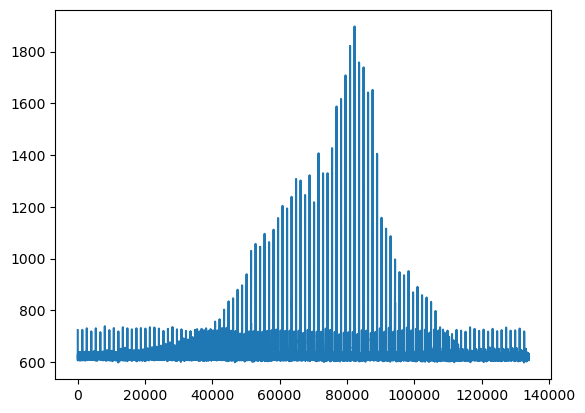

In [161]:
plt.plot(data[1:134000])

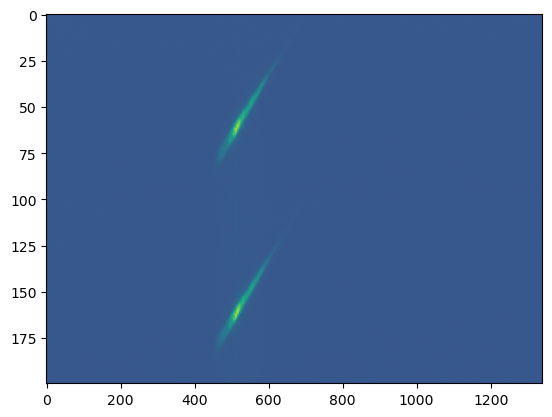

In [162]:
plt.imshow(d2d, aspect='auto', vmin=100, vmax=2000)

In [ ]:
processed_frames = []
for i in range(available_data.readout_count):
    readout = readouts[i]
    frame = (c_int64 * FIXED_FRAME_SIZE).from_address(ctypes.addressof(readout.data.contents))
    dataArrayType = ctypes.c_uint16 * int(FIXED_FRAME_SIZE) #readoutstride
    dataArrayPointerType = ctypes.POINTER(dataArrayType)
    dataPointer = ctypes.cast(available_data.initial_readout, dataArrayPointerType)
    
    processed_frames.append(list(frame))  # Convert to a Python list

In [57]:
controller.close_camera()